In [224]:
import numpy as np
import matplotlib.pyplot as plt
import Optimal_transport as OT


def Gradient(x0,f,h=1e-2):
    
    '''
    Approximate the Gradient vector of f at x0 using finite differences, knowing the value of f at every point of the domain

    x0: n-vecteur containing the parameter value at which the hessian should be evaluated

    f: Function that return a value for a list of parameter x


    '''

    dim=f.__code__.co_argcount
    Gradient=np.zeros((dim))    
    for i in range(dim):
            Gradient[i]= (f(*(x0+np.array([h/2 if k == i else 0 for k in range(dim)])))
                        -f(*(x0-np.array([h/2 if k == i else 0 for k in range(dim)]))))/h
      
    return Gradient


def steepest_descent(X0,f,num_iter_max=100,eps=1e-3,Xmin=[0,0],Xmax=[1,1],eta=1e-3,h=1e-2):
    """
    Compute the steepest descent algorithm
    
    Parameters
    ----------
    
    X0: array, starting position
    f: function to be minimised 
    num_iter_max: int, maximum number of iteration
    eps: float, precision for the final result
    Xmin: array, minimum bounds
    Xmax: array, maximum bounds
    eta: float, learning rate
    h: float, gradient evaluation precision
    
    
    Returns
    -------
    
    X: Final position
    Err: list of all errors from X0 to X
    Xs: list of all positions from X0 to X
    
    """
    
    dim=f.__code__.co_argcount

    X=X0
    Xs=[X0]
    Err=[]
    for i in range(num_iter_max):
        
        if all(list(map(lambda x,y,z : x>=y and x<=z, X,Xmin,Xmax))):
            Err.append(f(*X))
            
            dk=-1*eta*Gradient(X,f,h)
            if np.sum(abs(dk))<=eps:
                print('Descent finished')
                break
            X=X+dk
            Xs.append(X)
        else:
            Err.append(f(*X))
            print('X got out of bound')
            break
        if i==num_iter_max-1:
            print('Maximum number of iteration reached')
    return np.array(X),np.array(Err),np.array(Xs)

    
    
# Analytical solution of Welty (1994)



def diverging(t,alpha,R,Q,Phi,L,M=1,rho=1000):
        
    """
    Compute the Concentration of a tracer in a well in diverging radial flow a single injection according to Welty 1994
    
    Parameters
    ----------
    
    t: float, time at which the concentration is observed
    alpha: float, Longitudinal dispersivity (m)
    R: float, distance tracer imput to the well (m)
    Q: float, Discharge of the well (m3/s)
    Phi: float, Porosity (no units)
    L: float, Width of the aquifer(m)
    M: Mass of injected tracer (kg)
    rho: volumetric mass of water (kg/m3)
    
    Returns
    -------
    
    float, concentration in the well at t
    
    """
    
    tc=t/(R**2 *np.pi*Phi*L/Q)
    e=-1*(1-tc)**2/((16*alpha*tc**1.5)/(3*R))
    denom=np.sqrt(tc**1.5)
    c_norm=np.nan_to_num(np.exp(e)/denom)
    return c_norm*M/(rho*2*np.pi*Phi*L*(R**2)*np.sqrt(4*np.pi*alpha/(3*R)))


def multipeaks(times,t_start,alpha,R,Q,Phi,L,M=1,rho=1000): 
    """
    Compute the Concentration of a tracer in a well in diverging radial flow with multiple injections according to Welty 1994
    
    Parameters
    ----------
    
    times: List or numpy Array, contains the time steps
    t_start: List or numpy Array, contains the starting times of all the injections
    alpha: float, Longitudinal dispersivity (m)
    R: float, distance tracer imput to the well (m)
    Q: float, Discharge of the well (m3/s)
    Phi: float, Porosity (no units)
    L: float, Width of the aquifer(m)
    M: Mass of injected tracer (kg)
    rho: volumetric mass of water (kg/m3)
    
    Returns
    -------
    
    List or numpy Array, contains the concentration in the well for every time steps of t
    
    """
    
    res=np.zeros(len(times))
    for k in range(len(t_start)):
        t=times-t_start[k]
        res[t>0]+=diverging(t[t>0],alpha,R,Q,Phi,L,M=M,rho=rho)
    return res







alpha_target=1
phi_target=0.15

seconds_in_day=3600*24
times=np.linspace(100,seconds_in_day*100,200)
cs_target=multipeaks(times,[0,20*seconds_in_day],alpha=alpha_target,R=220,Q=10000/1000/60,Phi=phi_target,L=20)



In [225]:
cs_noise=multipeaks(times,[0,20*seconds_in_day],alpha=alpha_target,R=220,Q=10000/1000/60,Phi=phi_target,L=20)

In [226]:
def add_noise(ts,std_dev,mean=0):

    noise = np.random.normal(mean, std_dev, ts.shape)
    noisy_ts = ts + noise

    return np.clip(noisy_ts,0,None)


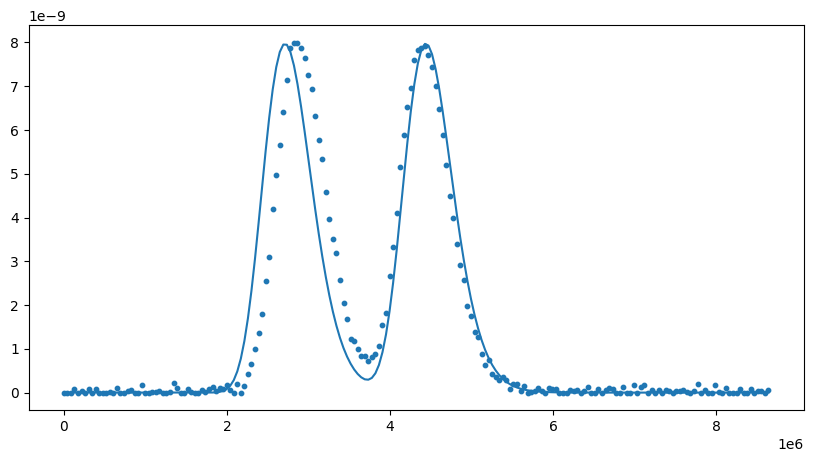

In [227]:
ndays=2
std_dev=.2e-9
random_time_shift1=(np.random.random()-0.5)*seconds_in_day*ndays*2
random_time_shift2=(np.random.random()-0.5)*seconds_in_day*ndays*2
cs_noise=add_noise(multipeaks(times,[0+random_time_shift1,20*seconds_in_day+random_time_shift2],alpha=alpha_target,
                              R=220,Q=10000/1000/60,Phi=phi_target,L=20),
                              std_dev=.1e-9)


plt.figure(figsize=(10,5))
plt.plot(times,cs_target)
plt.scatter(times,cs_noise,s=10)

In [215]:
def f_L2(x):
    """
    Objective fonction using L2 distances
    
    Parameters
    ----------
    
    alpha_n: float between 0 and 1, normalised dispersivity
    phi_n: float between 0 and 1, normalised porosity
    
    Returns
    -------
    
    float, L2 error
    
    """
    alpha_n,phi_n=x
    alpha=10**(alpha_n*2-1)
    phi=10**(phi_n-1.3)
    cs=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)
    
    return np.sum(((cs-cs_noise)/np.max(cs_noise))**2) 

In [216]:
def f_WD(x):

    """
    Objective fonction using Wasserstein distances
    
    Parameters
    ----------
    
    alpha_n: float between 0 and 1, normalised dispersivity
    phi_n: float between 0 and 1, normalised porosity
    
    Returns
    -------
    
    float, Wasserstein distance error
    
    """
    alpha_n,phi_n=x
    alpha=10**(alpha_n*2-1)
    phi=10**(phi_n-1.3)
    
    cs=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)
    
    return OT.optimal_transport(times,cs_noise,times,cs,reg=1)/np.max(cs_noise) 

In [217]:
def f_Sinkhorn(x):
    """
    Objective fonction using Sinkhorn distances
    
    Parameters
    ----------
    
    alpha_n: float between 0 and 1, normalised dispersivity
    phi_n: float between 0 and 1, normalised porosity
    
    Returns
    -------
    
    float, Sinkhorn error
    
    """
    alpha_n,phi_n=x
    alpha=10**(alpha_n*2-1)
    phi=10**(phi_n-1.3)
    
    cs=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)
    
    return OT.optimal_transport(times,cs_noise,times,cs,Sinkhorn_dist=True,reg=1,logeps=3,NumIterMax=200,k1=.2,k2=1)/np.max(cs_target)

In [218]:
x = np.linspace(0, 1, 50)
y = np.linspace(0, 1, 50)
X, Y = np.meshgrid(x, y)
Z_L2 = np.zeros((50,50))
Z_WD = np.zeros((50,50))
Z_Sinkhorn = np.zeros((50,50))
for i in range(50):
    print(i)
    for j in range(50):
        Z_L2[i,j]=f_L2([X[i,j],Y[i,j]])
        Z_WD[i,j]=f_WD([X[i,j],Y[i,j]])
        Z_Sinkhorn[i,j]=f_Sinkhorn([X[i,j],Y[i,j]])


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


[Recuit] Fin de la phase exploratoire.
         Position brute trouvée : [0.56483546 0.48084579]
         Score brut : 0.456713

[Hybride] Fin du polissage local (Nelder-Mead).
          Position finale exacte : [0.56334476 0.47982915]
          Score final exact : 0.456124


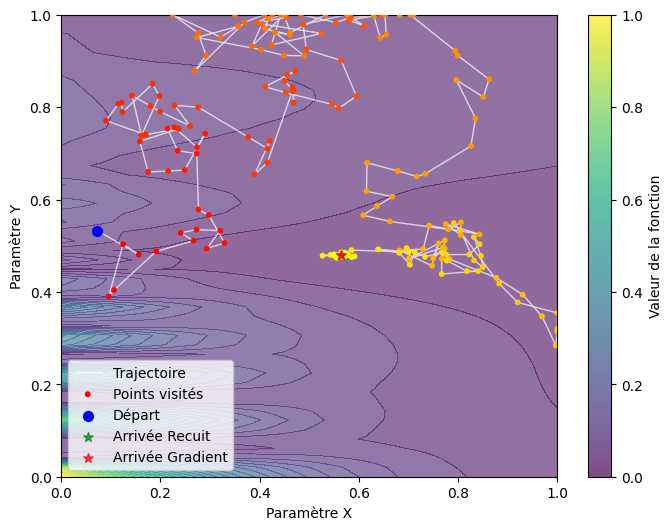

In [219]:
import numpy as np
from scipy.optimize import minimize

def recuit_simule_hybride(fonction, bornes, n_iterations=2000, temp_initiale=1, alpha=0.98, taille_pas=0.05):
    b_min, b_max = np.array(bornes)[:, 0], np.array(bornes)[:, 1]
    

    etat_actuel = b_min + np.random.rand(2) * (b_max - b_min)
    score_actuel = fonction(etat_actuel)
    
    meilleur_etat = etat_actuel.copy()
    meilleur_score = score_actuel
    
    t = temp_initiale
    
    historique = [etat_actuel.copy()]
    
    for i in range(n_iterations):
        bruit = np.random.normal(0, taille_pas, size=2)
        candidat = np.clip(etat_actuel + bruit, b_min, b_max)
        score_candidat = fonction(candidat)
        
        diff = score_candidat - score_actuel
        if diff < 0 or np.random.rand() < np.exp(-diff / t):
            etat_actuel, score_actuel = candidat, score_candidat
            historique.append(etat_actuel.copy())
            if score_candidat < meilleur_score:
                meilleur_score = score_candidat
                meilleur_estado = candidat.copy()
                
        t = t * alpha

    print(output := f"[Recuit] Fin de la phase exploratoire.")
    print(f"         Position brute trouvée : {meilleur_estado}")
    print(f"         Score brut : {meilleur_score:.6f}")


    res = minimize(
        fonction, 
        x0=meilleur_estado, 
        bounds=bornes, 
        method='Nelder-Mead',
        options={'xatol': 1e-6, 'fatol': 1e-6}
    )
    
    print(f"\n[Hybride] Fin du polissage local (Nelder-Mead).")
    print(f"          Position finale exacte : {res.x}")
    print(f"          Score final exact : {res.fun:.6f}")
    
    historique.append(res.x)

    return res.x, res.fun,np.array(historique)


meilleure_position_L2, meilleur_score_final,parcours = recuit_simule_hybride(f_L2, [[0,1],[0,1]],temp_initiale=10)

plt.figure(figsize=(8, 6))


plt.contourf(X, Y, Z_L2, levels=30, cmap='viridis', alpha=0.6)
plt.plot(parcours[:, 0], parcours[:, 1], color='white', linestyle='-', linewidth=1, alpha=0.7, label='Trajectoire')
plt.scatter(parcours[:, 0], parcours[:, 1], c=range(len(parcours)), cmap='autumn', s=10, zorder=3, label='Points visités')

plt.scatter(parcours[0, 0], parcours[0, 1], color='blue', s=50, marker='o', zorder=5, label='Départ')
plt.scatter(parcours[-2, 0], parcours[-2, 1], color='green', s=50, marker='*', zorder=5, label='Arrivée Recuit',alpha=.7)
plt.scatter(parcours[-1, 0], parcours[-1, 1], color='red', s=50, marker='*', zorder=5, label='Arrivée Gradient',alpha=.7)
plt.colorbar(label='Valeur de la fonction')
plt.legend()
plt.xlabel("Paramètre X")
plt.ylabel("Paramètre Y")
plt.show()

[Recuit] Fin de la phase exploratoire.
         Position brute trouvée : [0.53159032 0.48065089]
         Score brut : 0.003957

[Hybride] Fin du polissage local (Nelder-Mead).
          Position finale exacte : [0.53463986 0.48079449]
          Score final exact : 0.003956


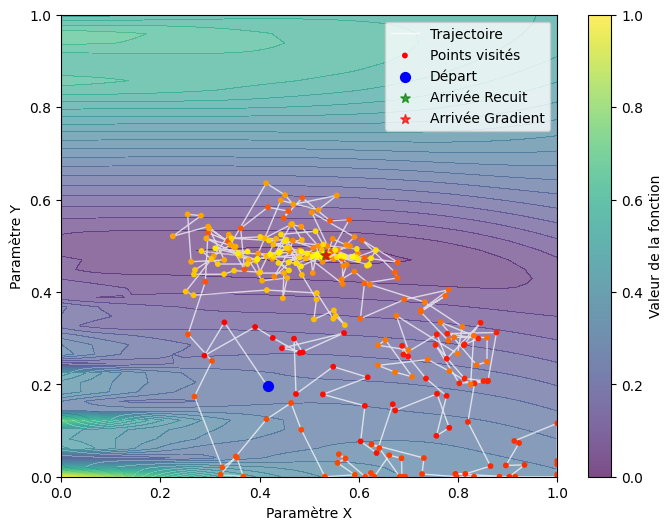

In [220]:
import numpy as np
from scipy.optimize import minimize

def recuit_simule_hybride(fonction, bornes, n_iterations=2000, temp_initiale=1, alpha=0.98, taille_pas=0.05):
    b_min, b_max = np.array(bornes)[:, 0], np.array(bornes)[:, 1]
    
    etat_actuel = b_min + np.random.rand(2) * (b_max - b_min)
    score_actuel = fonction(etat_actuel)
    
    meilleur_etat = etat_actuel.copy()
    meilleur_score = score_actuel
    
    t = temp_initiale
    
    historique = [etat_actuel.copy()]
    
    for i in range(n_iterations):

        bruit = np.random.normal(0, taille_pas, size=2)
        candidat = np.clip(etat_actuel + bruit, b_min, b_max)
        score_candidat = fonction(candidat)
        
        diff = score_candidat - score_actuel
        if diff < 0 or np.random.rand() < np.exp(-diff / t):
            etat_actuel, score_actuel = candidat, score_candidat
            historique.append(etat_actuel.copy())
            if score_candidat < meilleur_score:
                meilleur_score = score_candidat
                meilleur_estado = candidat.copy()
                
        t = t * alpha

    print(output := f"[Recuit] Fin de la phase exploratoire.")
    print(f"         Position brute trouvée : {meilleur_estado}")
    print(f"         Score brut : {meilleur_score:.6f}")

    res = minimize(
        fonction, 
        x0=meilleur_estado, 
        bounds=bornes, 
        method='Nelder-Mead',
        options={'xatol': 1e-6, 'fatol': 1e-6} 
    )
    
    print(f"\n[Hybride] Fin du polissage local (Nelder-Mead).")
    print(f"          Position finale exacte : {res.x}")
    print(f"          Score final exact : {res.fun:.6f}")
    
    historique.append(res.x)

    return res.x, res.fun,np.array(historique)


# Lancement de l'algorithme hybride
meilleure_position_WD, meilleur_score_final,parcours = recuit_simule_hybride(f_WD, [[0,1],[0,1]],temp_initiale=.5)

plt.figure(figsize=(8, 6))

# Création du fond (carte de chaleur de la fonction)

plt.contourf(X, Y, Z_WD, levels=30, cmap='viridis', alpha=0.6)
# Tracé du parcours de l'algorithme
plt.plot(parcours[:, 0], parcours[:, 1], color='white', linestyle='-', linewidth=1, alpha=0.7, label='Trajectoire')
plt.scatter(parcours[:, 0], parcours[:, 1], c=range(len(parcours)), cmap='autumn', s=10, zorder=3, label='Points visités')

# Points clés
plt.scatter(parcours[0, 0], parcours[0, 1], color='blue', s=50, marker='o', zorder=5, label='Départ')
plt.scatter(parcours[-2, 0], parcours[-2, 1], color='green', s=50, marker='*', zorder=5, label='Arrivée Recuit',alpha=.7)
plt.scatter(parcours[-1, 0], parcours[-1, 1], color='red', s=50, marker='*', zorder=5, label='Arrivée Gradient',alpha=.7)
plt.colorbar(label='Valeur de la fonction')

plt.xlabel("Paramètre X")
plt.ylabel("Paramètre Y")
plt.legend()
plt.show()

[Recuit] Fin de la phase exploratoire.
         Position brute trouvée : [0.53269818 0.48141098]
         Score brut : 0.005695

[Hybride] Fin du polissage local (Nelder-Mead).
          Position finale exacte : [0.54388943 0.47991403]
          Score final exact : 0.005692


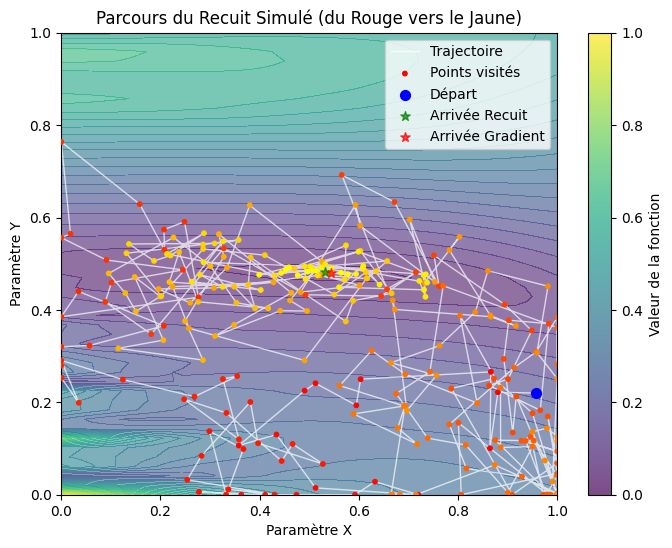

In [221]:
import numpy as np
from scipy.optimize import minimize

def recuit_simule_hybride(fonction, bornes, n_iterations=2000, temp_initiale=1, alpha=0.98, taille_pas=0.1):
    b_min, b_max = np.array(bornes)[:, 0], np.array(bornes)[:, 1]
    
    # 1. Initialisation
    etat_actuel = b_min + np.random.rand(2) * (b_max - b_min)
    score_actuel = fonction(etat_actuel)
    
    # --- CRUCIAL : On garde une trace du meilleur absolu trouvé ---
    meilleur_etat = etat_actuel.copy()
    meilleur_score = score_actuel
    
    t = temp_initiale
    
    historique = [etat_actuel.copy()]
    
    for i in range(n_iterations):
        # Générer un voisin
        bruit = np.random.normal(0, taille_pas, size=2)
        candidat = np.clip(etat_actuel + bruit, b_min, b_max)
        score_candidat = fonction(candidat)
        
        # Critère d'acceptation (Metropolis)
        diff = score_candidat - score_actuel
        if diff < 0 or np.random.rand() < np.exp(-diff / t):
            # Si accepté, on met à jour l'état
            etat_actuel, score_actuel = candidat, score_candidat
            historique.append(etat_actuel.copy())
            if score_candidat < meilleur_score:
                meilleur_score = score_candidat
                meilleur_estado = candidat.copy()
                
        t = t * alpha

    print(output := f"[Recuit] Fin de la phase exploratoire.")
    print(f"         Position brute trouvée : {meilleur_estado}")
    print(f"         Score brut : {meilleur_score:.6f}")

    # ==========================================
    # ÉTAPE 2 : L'Optimisation Locale (Précision)
    # ==========================================
    # On utilise Nelder-Mead en lui donnant le meilleur point du recuit comme départ
    res = minimize(
        fonction, 
        x0=meilleur_estado, 
        bounds=bornes, 
        method='Nelder-Mead',
        options={'xatol': 1e-6, 'fatol': 1e-6} # Précision très stricte
    )
    
    print(f"\n[Hybride] Fin du polissage local (Nelder-Mead).")
    print(f"          Position finale exacte : {res.x}")
    print(f"          Score final exact : {res.fun:.6f}")
    
    historique.append(res.x)

    return res.x, res.fun,np.array(historique)


# Lancement de l'algorithme hybride
meilleure_position, meilleur_score_final,parcours = recuit_simule_hybride(f_Sinkhorn, [[0,1],[0,1]],temp_initiale=1)

plt.figure(figsize=(8, 6))

# Création du fond (carte de chaleur de la fonction)

plt.contourf(X, Y, Z_WD, levels=30, cmap='viridis', alpha=0.6)
# Tracé du parcours de l'algorithme
plt.plot(parcours[:, 0], parcours[:, 1], color='white', linestyle='-', linewidth=1, alpha=0.7, label='Trajectoire')
plt.scatter(parcours[:, 0], parcours[:, 1], c=range(len(parcours)), cmap='autumn', s=10, zorder=3, label='Points visités')

# Points clés
plt.scatter(parcours[0, 0], parcours[0, 1], color='blue', s=50, marker='o', zorder=5, label='Départ')
plt.scatter(parcours[-2, 0], parcours[-2, 1], color='green', s=50, marker='*', zorder=5, label='Arrivée Recuit',alpha=.7)
plt.scatter(parcours[-1, 0], parcours[-1, 1], color='red', s=50, marker='*', zorder=5, label='Arrivée Gradient',alpha=.7)
plt.colorbar(label='Valeur de la fonction')
plt.title("Parcours du Recuit Simulé (du Rouge vers le Jaune)")
plt.xlabel("Paramètre X")
plt.ylabel("Paramètre Y")
plt.legend()
plt.show()

In [228]:
alpha_n,phi_n=meilleure_position_L2
alpha=10**(alpha_n*2-1)
phi=10**(phi_n-1.3)
    
cs_L2=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)

alpha_n,phi_n=meilleure_position_WD
alpha=10**(alpha_n*2-1)
phi=10**(phi_n-1.3)
    
cs_WD=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)

ValueError: x and y must be the same size

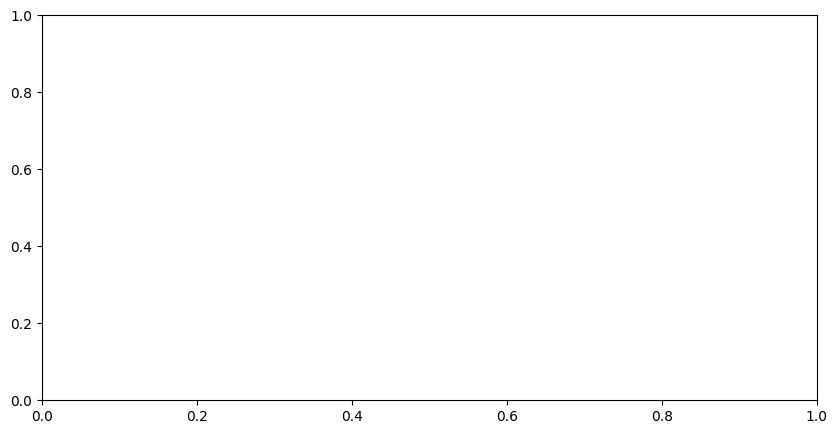

In [229]:
plt.figure(figsize=(10,5))

plt.scatter(np.linspace(100,seconds_in_day*100,30),cs_noise,s=10,label='data')
plt.plot(times,cs_L2,label='Best model-L2')
plt.plot(times,cs_WD,label='Best model-WD')
#plt.plot(times,cs_Sinkhorn,label='Sinkhorn')
plt.legend()